2.1 Exercise - 1:
Complete all the Task.
1. Read and display the image.

• Read the image using the Pillow library and display it.

• You can also use matplotlib to display the image.

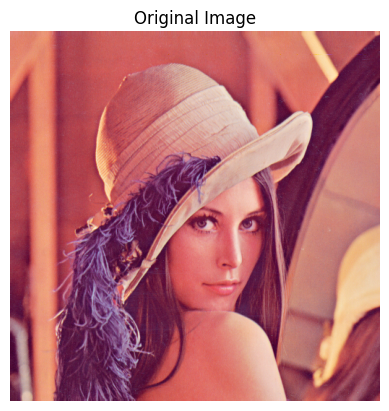

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Read the image
image = Image.open("Lenna!!.png")

# Display the image
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

2. Display only the top left corner of 100x100 pixels.

• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.

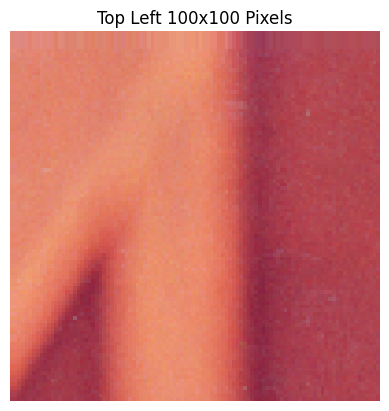

In [2]:
# Convert image to NumPy array
image_array = np.array(image)

# Extract top-left 100x100 pixels
top_left = image_array[0:100, 0:100]

# Display the extracted region
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Show the three color channels (R, G, B).

• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

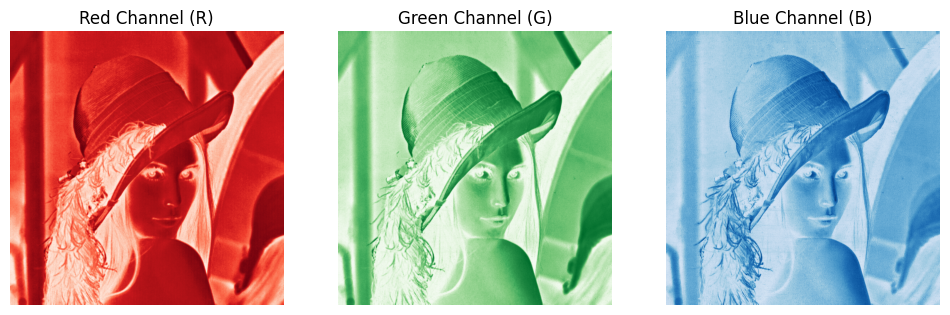

In [3]:
# Extract RGB channels
R = image_array[:, :, 0]
G = image_array[:, :, 1]
B = image_array[:, :, 2]

# Display each channel
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel (R)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel (G)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel (B)")
plt.axis("off")

plt.show()

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

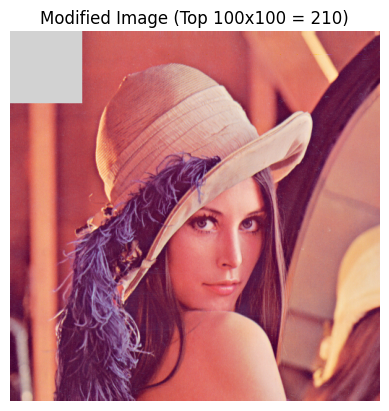

In [4]:
# Copy the original image array
modified_image = image_array.copy()

# Modify the top-left 100x100 pixels
modified_image[0:100, 0:100] = 210

# Display modified image
plt.imshow(modified_image)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

2.2 Exercise - 2:

Complete all the Task.

1. Load and display a grayscale image.

• Load a grayscale image using the Pillow library.

• Display the grayscale image using matplotlib.

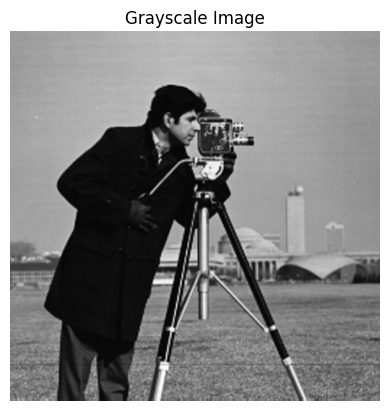

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the grayscale image
image = Image.open("cameraman.png").convert("L")

# Display the grayscale image
plt.imshow(image, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).

• Extract a 150 pixel section from the center of the image using NumPy array slicing.

• Display this cropped image using matplotlib.

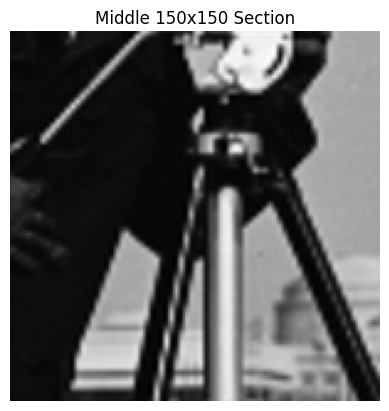

In [6]:
# Convert to NumPy array
image_array = np.array(image)

# Get image dimensions
height, width = image_array.shape

# Calculate center
center_y = height // 2
center_x = width // 2

# Extract 150x150 middle section
middle_section = image_array[
    center_y-75:center_y+75,
    center_x-75:center_x+75
]

# Display cropped section
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).

• Display the resulting binary image.

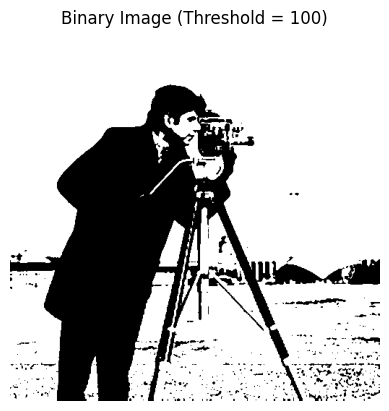

In [7]:
# Apply threshold
binary_image = image_array.copy()
binary_image[binary_image < 100] = 0
binary_image[binary_image >= 100] = 255

# Display binary image
plt.imshow(binary_image, cmap='gray')
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.

• Display the rotated image using matplotlib.

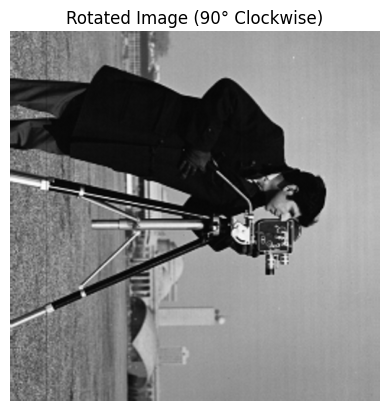

In [8]:
# Rotate 90 degrees clockwise
rotated_image = image.rotate(-90)

# Display rotated image
plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).

• Display the converted RGB image using matplotlib.

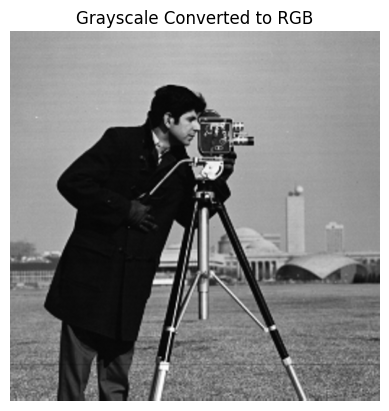

In [9]:
# Convert grayscale array to RGB
rgb_image = np.stack((image_array,)*3, axis=-1)

# Display RGB image
plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

3 Image Compression and Decompression using PCA.

In this exercise, build a PCA from scratch using explained variance method for image compression task.

You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.
1. Load and Prepare Data:

• Fetch an image of you choice.{If colour convert to grayscale}

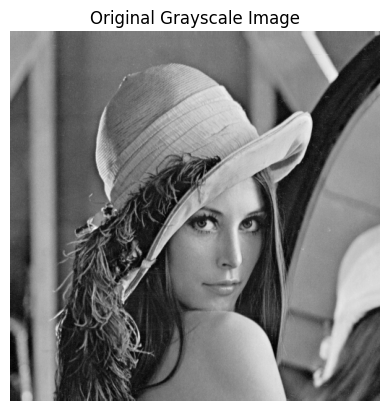

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
image = Image.open("Lenna!!.png").convert("L")   # Convert to grayscale

# Convert image to NumPy array
img_array = np.array(image)

# Display image
plt.imshow(img_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

• Center the dataset - Standaridze the Data.

In [11]:
# Compute mean
mean = np.mean(img_array, axis=0)

# Center the data
centered_data = img_array - mean

• Calculate the covaraince matrix of the Standaridze data.

In [12]:
cov_matrix = np.cov(centered_data, rowvar=False)

2. Eigen Decomposition and Identifying Principal Components:

• Compute Eigen Values and Eigen Vectors.


In [13]:
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.

In [14]:
# Sort eigenvalues and eigenvectors
sorted_index = np.argsort(eigen_values)[::-1]

sorted_eigenvalues = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

• Identify the Principal Components with the help of cumulative Sum plot.

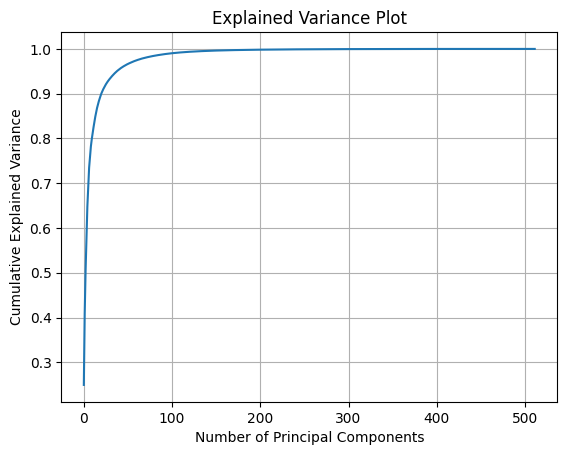

In [15]:
# Explained variance
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

3 Image Compression and Decompression using PCA.

In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.

1. Load and Prepare Data:

• Fetch an image of you choice.{If colour convert to grayscale}

• Center the dataset - Standaridze the Data.

• Calculate the covaraince matrix of the Standaridze data.

2. Eigen Decomposition and Identifying Principal Components:

• Compute Eigen Values and Eigen Vectors.

• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.

• Identify the Principal Components with the help of cumulative Sum plot.

3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate.

In [16]:
def pca_compress(data, eigenvectors, k):

    # Select top k eigenvectors
    PCs = eigenvectors[:, :k]

    # Project data to lower dimension
    compressed = np.dot(data, PCs)

    # Reconstruct image
    reconstructed = np.dot(compressed, PCs.T)

    return reconstructed

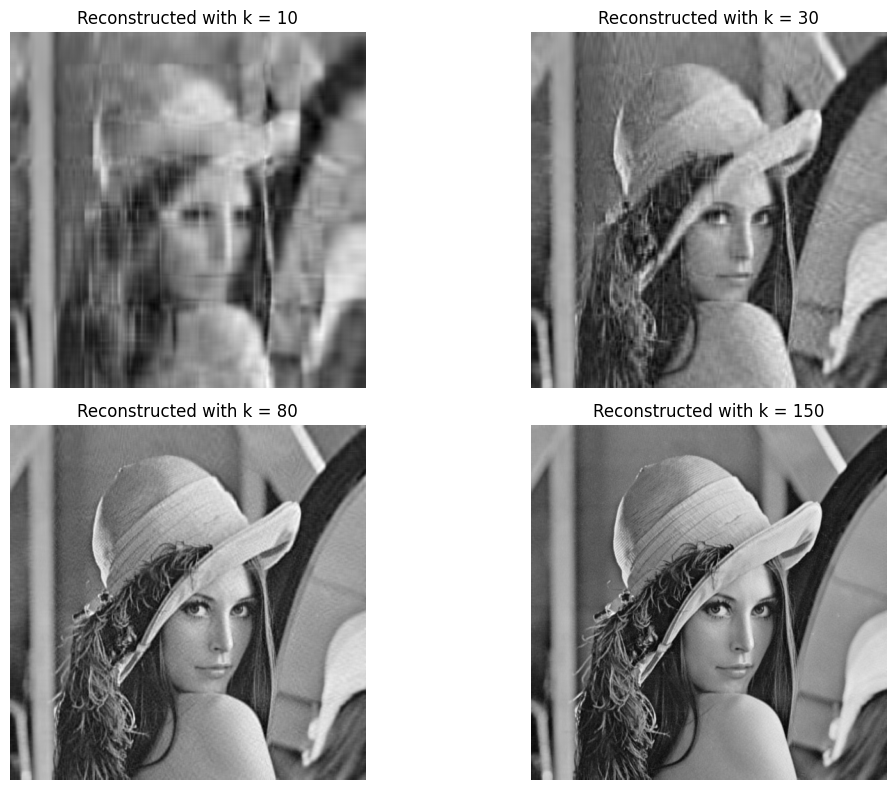

In [17]:
k_values = [10, 30, 80, 150]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):

    reconstructed = pca_compress(centered_data, sorted_eigenvectors, k)

    # Add mean back
    reconstructed = reconstructed + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"Reconstructed with k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()